# Checking out the subscale flight profiles to see how far the rocket dropped before parachute deployment

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.interpolate as interpolate

# plt.rcParams['font.family'] = 'Times New Roman'
# plt.rcParams['figure.titlesize'] = 20
# plt.rcParams['figure.titleweight'] = 'bold'
# plt.rcParams['figure.figsize'] = (10, 8)
# plt.rcParams['axes.titlesize'] = 16
# plt.rcParams['axes.labelsize'] = 14
# plt.rcParams['figure.labelsize'] = 14
# plt.rcParams['xtick.labelsize'] = 12
# plt.rcParams['ytick.labelsize'] = 12
# plt.rcParams['legend.fontsize'] = 12
# plt.rcParams['mathtext.fontset'] = 'cm'

plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['figure.titlesize'] = 22
plt.rcParams['figure.titleweight'] = 'bold'
plt.rcParams['figure.figsize'] = (10, 8)
plt.rcParams['axes.titlesize'] = 20
plt.rcParams['axes.labelsize'] = 20
plt.rcParams['figure.labelsize'] = 20
plt.rcParams['xtick.labelsize'] = 20
plt.rcParams['ytick.labelsize'] = 20
plt.rcParams['legend.fontsize'] = 18
plt.rcParams['mathtext.fontset'] = 'cm'

Function to plot OpenRocket data

In [4]:
def openrocket_to_plot(file_path, code_to_run=None, **kwargs):
    # Reading in data
    df = pd.read_csv(file_path, comment='#')
    
    # Reading in events
    with open(file_path, 'r') as f:
        lines = f.readlines()
        event_lines = [line for line in lines if line.startswith('#')]

    # Extracting event names
    events = [line.split('Event ')[1].split(' occurred at t=')[0] for line in event_lines]

    # Extracting event times
    event_times = [float(line.split('t=')[1].split(' seconds')[0]) for line in event_lines]

    # Defining events to plot
    plot_events = ['LAUNCH', 'BURNOUT', 'APOGEE', 'RECOVERY_DEVICE_DEPLOYMENT', 'GROUND_HIT']

    # Plotting flight profile
    fig = plt.figure()
    fig.set_tight_layout(kwargs.get('tight_layout', True))
    
    ax = fig.add_subplot()

    if code_to_run is not None:
        exec(code_to_run)

    elif kwargs.get('plot_type', 'altitude') == 'altitude':
        ax.plot(df['Time (s)'], df['Altitude (ft)'], linestyle=kwargs.get('linestyle', '-'), color=kwargs.get('color', 'b'), label=kwargs.get('label', None), linewidth=kwargs.get('linewidth', 2))
        ax.set_ylabel('Altitude [ft]')

    elif kwargs.get('plot_type') == 'velocity':
        ax.plot(df['Time (s)'], df['Total velocity (ft/s)'], linestyle=kwargs.get('linestyle', '-'), color=kwargs.get('color', 'b'), label=kwargs.get('label', None), linewidth=kwargs.get('linewidth', 2))
        ax.set_ylabel('Velocity [ft/s]')

    elif kwargs.get('plot_type') == 'all':
        ax.plot(df['Time (s)'], df['Altitude (ft)'], linestyle=kwargs.get('linestyle', '-'), color='b', label='Altitude', linewidth=kwargs.get('linewidth', 2))
        ax.plot(df['Time (s)'], df['Total velocity (ft/s)'], linestyle=kwargs.get('linestyle', '--'), color='r', label='Velocity', linewidth=kwargs.get('linewidth', 2))
        ax.set_ylabel('Altitude [ft], Velocity [ft/s]')

        ax2 = ax.twinx()
        ax2.plot(df['Time (s)'], df['Total acceleration (ft/s²)'], linestyle=kwargs.get('linestyle', '-.'), color='g', label='Acceleration', linewidth=kwargs.get('linewidth', 2))
        ax2.set_ylabel('Acceleration [ft/s²]')

    drogue_deployed = False
    for event, event_time in zip(events, event_times):
        if event in plot_events:
            ax.axvline(event_time, linestyle='--', color='k')

            if event == 'RECOVERY_DEVICE_DEPLOYMENT':
                if not drogue_deployed:
                    # Label on right side near middle
                    event_label = 'Drogue Deployment'
                    drogue_deployed = True
                    ax.text(event_time + 0.5, np.mean(ax.get_ylim()), event_label, rotation=90, verticalalignment='center', horizontalalignment='left', fontsize=20)
                else:
                    # Label on left side near top
                    event_label = 'Main Deployment'
                    ax.text(event_time - 0.3, 0.99 * ax.get_ylim()[1], event_label, rotation=90, verticalalignment='top', horizontalalignment='right', fontsize=20)

            elif event == 'BURNOUT':
                # Label on right side near top
                ax.text(event_time + 0.5, 0.99 * ax.get_ylim()[1], event.replace('_', ' ').title(), rotation=90, verticalalignment='top', horizontalalignment='left', fontsize=20)

            elif event == 'APOGEE' or event == 'GROUND_HIT':
                # Label on left side near middle
                ax.text(event_time - 0.3, np.mean(ax.get_ylim()), event.replace('_', ' ').title(), rotation=90, verticalalignment='center', horizontalalignment='right', fontsize=20)
            else:
                # Label on left side near top
                ax.text(event_time - 0.3, 0.99 * ax.get_ylim()[1], event.replace('_', ' ').title(), rotation=90, verticalalignment='top', horizontalalignment='right', fontsize=20)

    # fig.suptitle('Simulated Flight Profile', y=0.95)
    ax.set_xlabel('Time [s]')
    ax.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

    if kwargs.get('label', None) is not None: ax.legend(loc='upper right')

    if kwargs.get('plot_type') == 'all':
        return fig, ax, ax2
    return fig, ax
    

## First, we start with simulated flight profiles

Reading in simulated flight profile data from OpenRocket

In [5]:
data_sim_launch_cond = pd.read_csv('Subscale OpenRocket Launch Conditions.csv', comment='#')
data_sim_standard_cond = pd.read_csv('Subscale OpenRocket Standard Conditions.csv', comment='#')

Plotting simulated flights with different environmental conditions

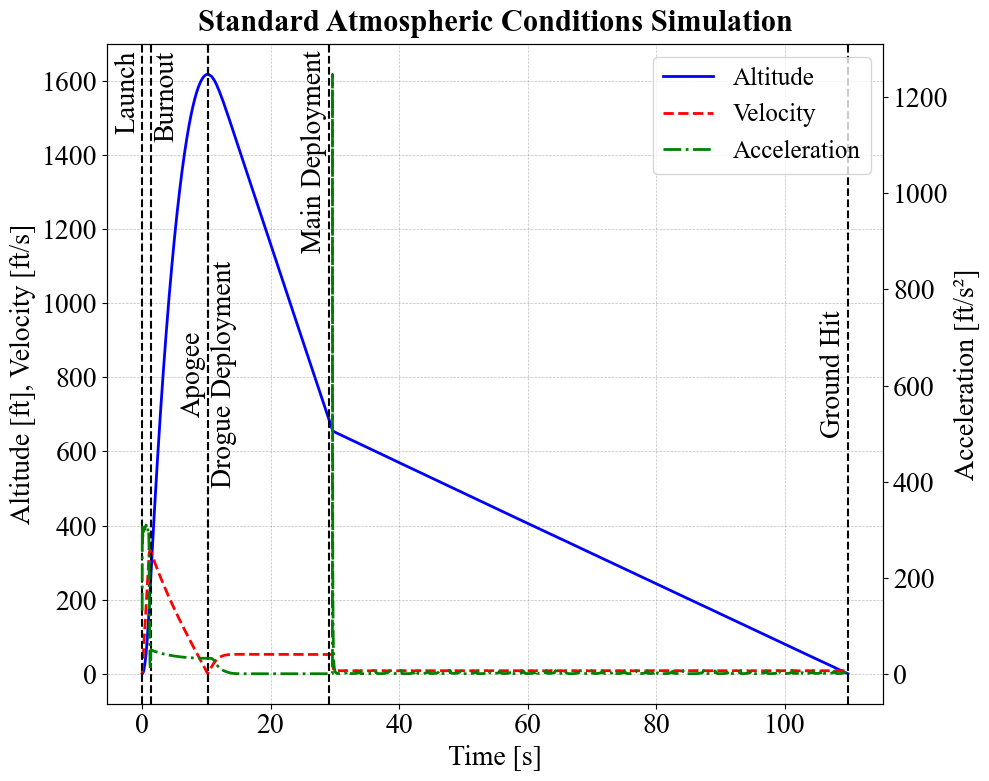

In [6]:
fig, ax1, ax2 = openrocket_to_plot('Subscale OpenRocket Standard Conditions.csv', plot_type='all')

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()

ax1.legend(h1 + h2, l1 + l2, loc='upper right')
fig.suptitle('Standard Atmospheric Conditions Simulation', y=0.97)

# fig.savefig('Subscale Standard Atmospheric Conditions Simulation.png', dpi=300)

plt.show()

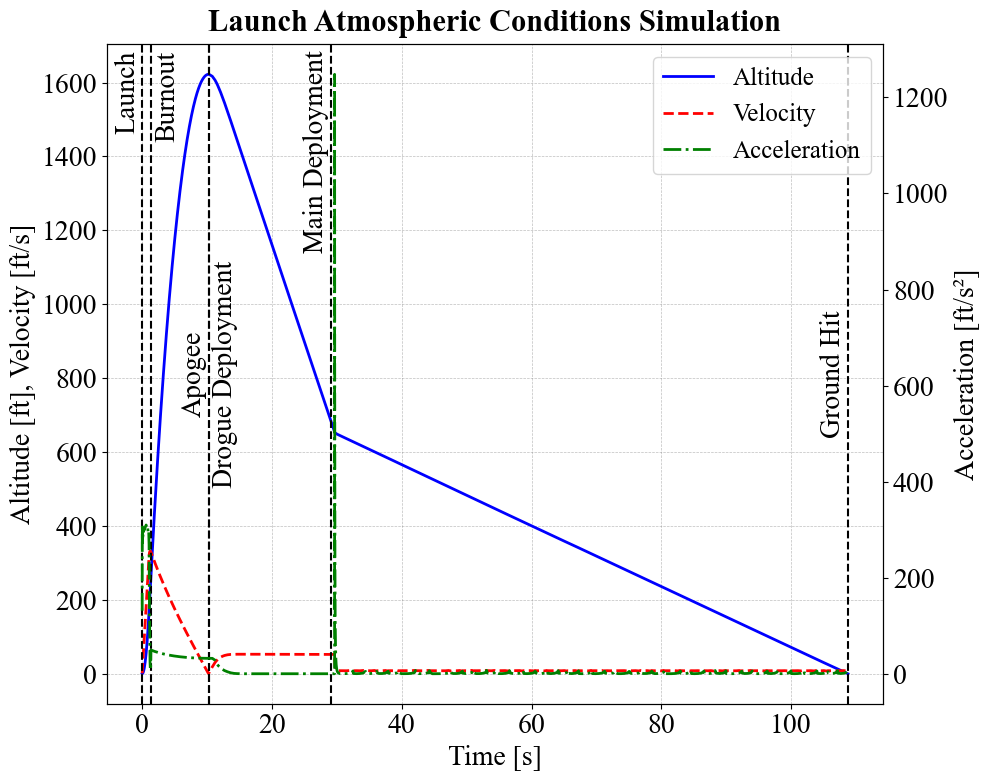

In [7]:
fig, ax1, ax2 = openrocket_to_plot('Subscale OpenRocket Launch Conditions.csv', plot_type='all')

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()

ax1.legend(h1 + h2, l1 + l2, loc='upper right')
fig.suptitle('Launch Atmospheric Conditions Simulation', y=0.97)

# fig.savefig('Subscale Launch Atmospheric Conditions Simulation.png', dpi=300)

plt.show()

In [63]:
# Drogue parachute fit
drogue_descent_velocities_standard_cond = data_sim_standard_cond['Total velocity (ft/s)'][(data_sim_standard_cond['Time (s)'] > 14) & (data_sim_standard_cond['Time (s)'] < 27)]
drogue_descent_velocities_launch_cond = data_sim_launch_cond['Total velocity (ft/s)'][(data_sim_launch_cond['Time (s)'] > 14) & (data_sim_launch_cond['Time (s)'] < 27)]

print(f'Drogue Descent Rate under Standard Conditions: {np.mean(drogue_descent_velocities_standard_cond):.2f} ft/s')
print(f'Drogue Descent Rate under Launch Conditions: {np.mean(drogue_descent_velocities_launch_cond):.2f} ft/s')

# Main parachute fit
main_descent_velocities_standard_cond = data_sim_standard_cond['Total velocity (ft/s)'][(data_sim_standard_cond['Time (s)'] > 32) & (data_sim_standard_cond['Time (s)'] < 90)]
main_descent_velocities_launch_cond = data_sim_launch_cond['Total velocity (ft/s)'][(data_sim_launch_cond['Time (s)'] > 32) & (data_sim_launch_cond['Time (s)'] < 90)]
print(f'Main Descent Rate under Standard Conditions: {np.mean(main_descent_velocities_standard_cond):.2f} ft/s')
print(f'Main Descent Rate under Launch Conditions: {np.mean(main_descent_velocities_launch_cond):.2f} ft/s')

Drogue Descent Rate under Standard Conditions: 52.30 ft/s
Drogue Descent Rate under Launch Conditions: 52.66 ft/s
Main Descent Rate under Standard Conditions: 8.17 ft/s
Main Descent Rate under Launch Conditions: 8.24 ft/s


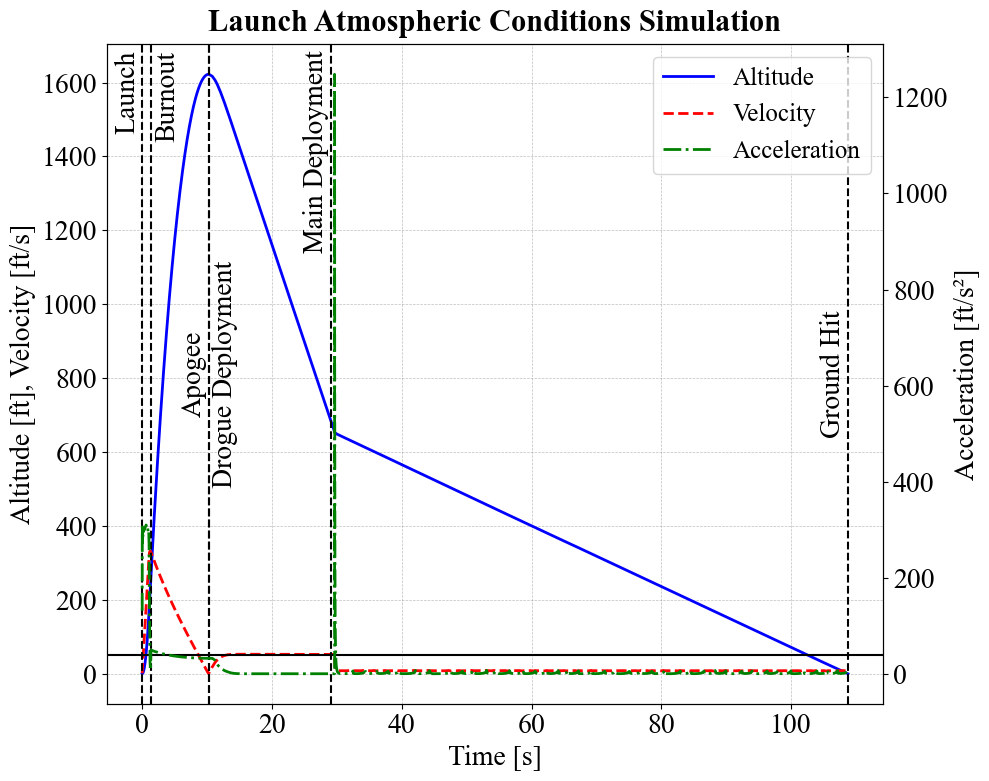

In [56]:
fig, ax1, ax2 = openrocket_to_plot('Subscale OpenRocket Launch Conditions.csv', plot_type='all')

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()

ax1.legend(h1 + h2, l1 + l2, loc='upper right')
fig.suptitle('Launch Atmospheric Conditions Simulation', y=0.97)

ax1.axhline(52, color='k')

fig.savefig('Test.png', dpi=300)

plt.show()

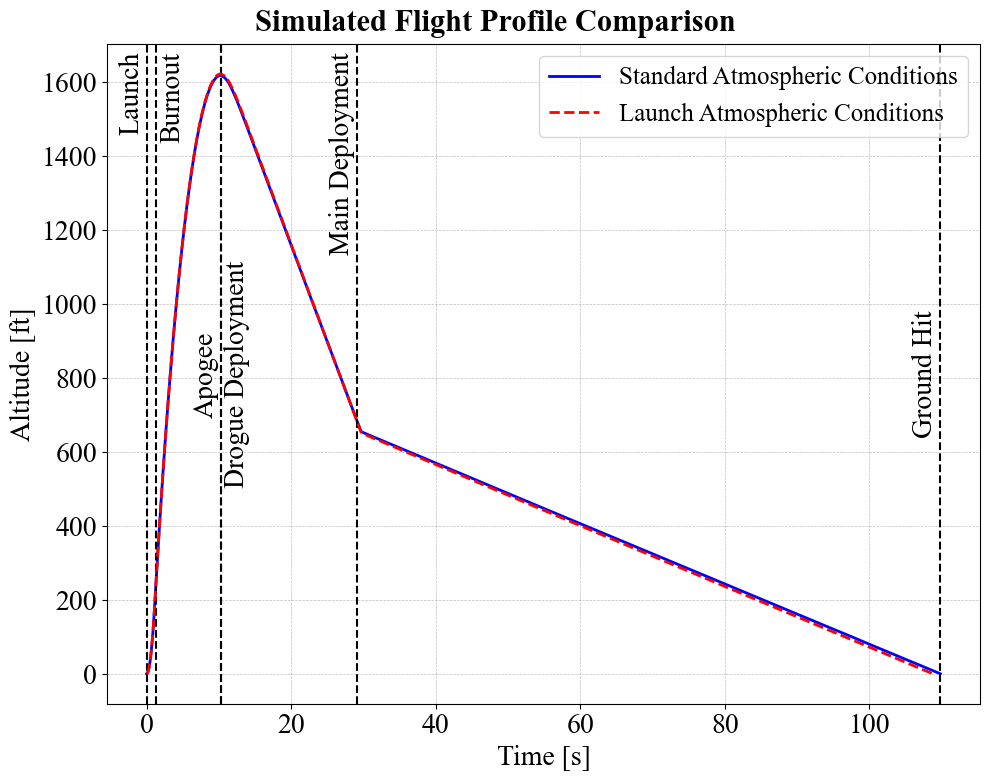

In [8]:
fig, ax = openrocket_to_plot('Subscale OpenRocket Standard Conditions.csv', color='b', label='Standard Atmospheric Conditions', linestyle='-')

ax.plot(data_sim_launch_cond['Time (s)'], data_sim_launch_cond['Altitude (ft)'], linestyle='--', color='r', label='Launch Atmospheric Conditions', linewidth=2)

ax.legend(loc='upper right')
fig.suptitle('Simulated Flight Profile Comparison', y=0.97)

# fig.savefig('Subscale Simulated Flight Profile Comparison.png', dpi=300)

plt.show()

Comparing the two different conditions through interpolation and plotting

In [9]:
# Comparing datasets by interpolating the altitudes
sim_common_times = np.linspace(0, max(data_sim_standard_cond['Time (s)'].max(), data_sim_launch_cond['Time (s)'].max()), num=1000)

interp_sim_standard = interpolate.interp1d(data_sim_standard_cond['Time (s)'], data_sim_standard_cond['Altitude (ft)'], kind='linear', fill_value=0, bounds_error=False)
interp_sim_launch = interpolate.interp1d(data_sim_launch_cond['Time (s)'], data_sim_launch_cond['Altitude (ft)'], kind='linear', fill_value=0, bounds_error=False)

interp_altitudes_standard = interp_sim_standard(sim_common_times)
interp_altitudes_launch = interp_sim_launch(sim_common_times)

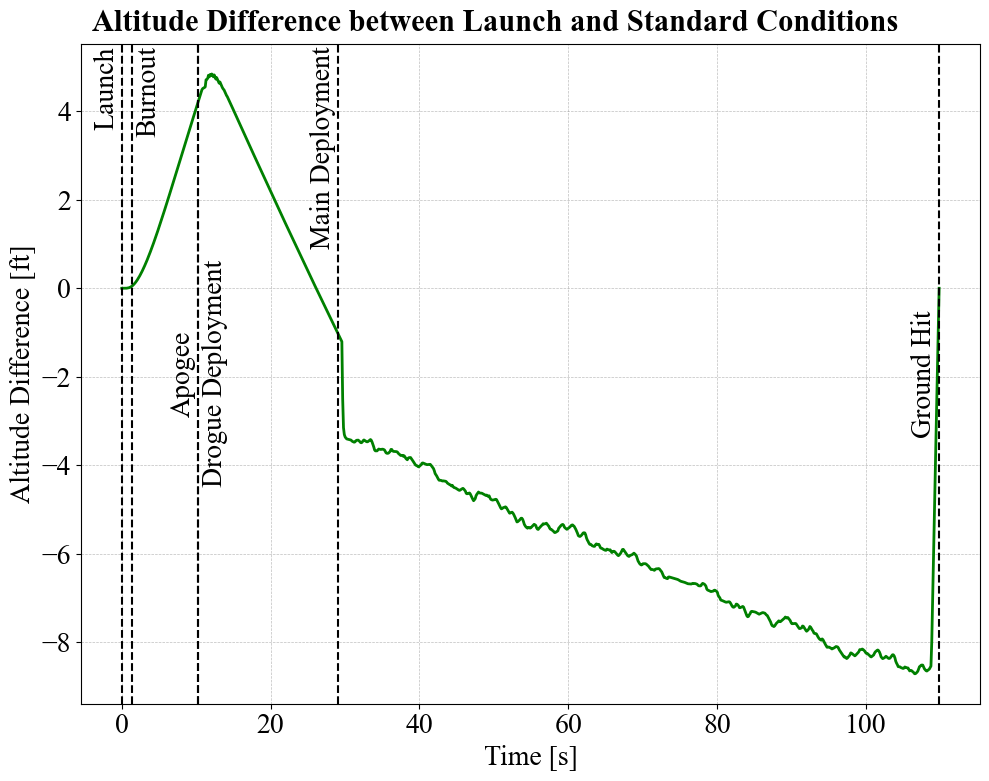

In [10]:
fig, ax = openrocket_to_plot('Subscale OpenRocket Standard Conditions.csv', code_to_run="ax.plot(sim_common_times, interp_altitudes_launch - interp_altitudes_standard, linestyle='-', color='g', label='Launch - Standard', linewidth=2)")
# fig = plt.figure()
# fig.set_tight_layout(True)
# ax = fig.add_subplot()

# ax.plot(sim_common_times, interp_altitudes_launch - interp_altitudes_standard, linestyle='-', color='g', label='Launch - Standard', linewidth=2)

fig.suptitle('Altitude Difference between Launch and Standard Conditions', y=0.97)
ax.set_xlabel('Time [s]')
ax.set_ylabel('Altitude Difference [ft]')

# ax.grid(True)

# fig.savefig('Subscale Altitude Difference Launch vs Standard Conditions.png', dpi=300)

plt.show()

## Now, we compare simulated flight data with actual flight data

Reading data

In [11]:
data_avionics = pd.read_csv('Subscale Telemega.csv')
data_payload = pd.read_csv('Subscale Payload.csv')

Changing avionics data to remove erroneous points

In [12]:
data_avionics2 = data_avionics.assign(**{'Altitude [ft]': data_avionics['height'] * 3.28084, 'Time [s]': data_avionics['time'], 'Acceleration [ft/s²]': data_avionics['acceleration'] * 3.28084, 'Velocity [ft/s]': data_avionics['speed'] * 3.28084})
data_avionics2 = data_avionics2[data_avionics2['Time [s]'].values < 50]

# Deleting error point before apogee
data_avionics2 = data_avionics2.drop(index=data_avionics2[(data_avionics2['Time [s]'] > 9) & (data_avionics2['Time [s]'] < 10) & (data_avionics2['Altitude [ft]'] < 1500)].index).reset_index(drop=True)

Cutting data to only include flight

In [13]:
start_time = 5464.5
end_time = start_time + 50

data_payload2 = data_payload[(data_payload['Time [s]'].values > start_time) & (data_payload['Time [s]'].values < end_time)]
data_payload2 = data_payload2.assign(**{'Time [s]': data_payload2['Time [s]'] - start_time, 'Altitude [ft]': (data_payload2['Altitude [m]'] - data_payload2['Altitude [m]'].values[0]) * 3.28084}).reset_index(drop=True)

Identifying the different phases of flight (boost, coast, apogee, drogue descent, main descent)

In [14]:
# Apogee
apogee_avionics = np.max(data_avionics2['Altitude [ft]'])
apogee_payload = np.max(data_payload2['Altitude [ft]'])
print(f'Apogee (Avionics): {apogee_avionics:.2f} ft')
print(f'Apogee (Payload): {apogee_payload:.2f} ft')

# Time to Apogee
time_to_apogee_avionics = data_avionics2['Time [s]'][np.argmax(data_avionics2['Altitude [ft]'])]
time_to_apogee_payload = data_payload2['Time [s]'][np.argmax(data_payload2['Altitude [ft]'])]
print(f'Time to Apogee (Avionics): {time_to_apogee_avionics:.2f} s')
print(f'Time to Apogee (Payload): {time_to_apogee_payload:.2f} s')

Apogee (Avionics): 1618.34 ft
Apogee (Payload): 1625.31 ft
Time to Apogee (Avionics): 10.40 s
Time to Apogee (Payload): 9.85 s


In [24]:
# Velocity
data_avionics2['Velocity [ft/s]'] = data_avionics2['speed'] * 3.28084
data_payload2['Velocity [ft/s]'] = np.gradient(data_payload2['Altitude [ft]'], data_payload2['Time [s]'])
print(f'Maximum Velocity (Avionics): {np.max(data_avionics2["Velocity [ft/s]"]):.2f} ft/s')
print(f'Maximum Velocity (Payload): {np.max(data_payload2["Velocity [ft/s]"]):.2f} ft/s')

# Time to Maximum Velocity
time_to_max_velocity_avionics = data_avionics2['Time [s]'][np.argmax(data_avionics2['Velocity [ft/s]'])]
time_to_max_velocity_payload = data_payload2['Time [s]'][np.argmax(data_payload2['Velocity [ft/s]'])]
print(f'Time to Maximum Velocity (Avionics): {time_to_max_velocity_avionics:.2f} s')
print(f'Time to Maximum Velocity (Payload): {time_to_max_velocity_payload:.2f} s')

Maximum Velocity (Avionics): 341.83 ft/s
Maximum Velocity (Payload): 365.89 ft/s
Time to Maximum Velocity (Avionics): 1.07 s
Time to Maximum Velocity (Payload): 1.40 s


In [25]:
# Acceleration
print(f'Maximum Acceleration (Avionics): {np.max(data_avionics2["Acceleration [ft/s²]"]):.2f} ft/s²')

# Time to Maximum Acceleration
time_to_max_acceleration_avionics = data_avionics2['Time [s]'][np.argmax(data_avionics2['Acceleration [ft/s²]'])]
print(f'Time to Maximum Acceleration (Avionics): {time_to_max_acceleration_avionics:.2f} s')

Maximum Acceleration (Avionics): 482.61 ft/s²
Time to Maximum Acceleration (Avionics): -0.09 s


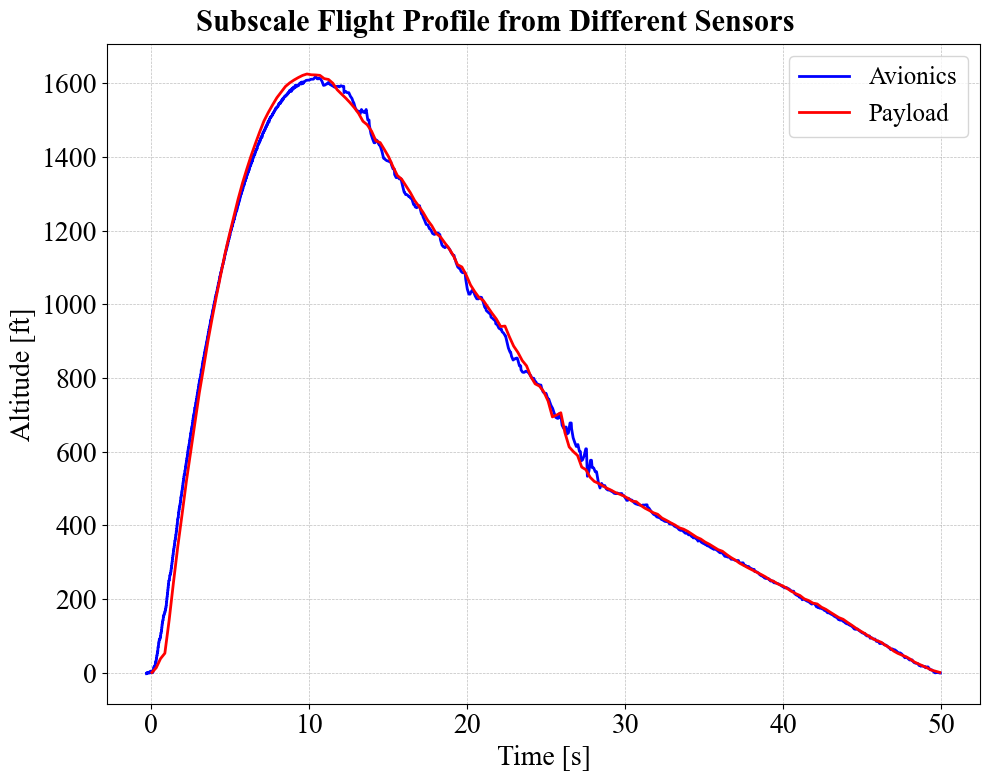

In [26]:
fig = plt.figure()
fig.set_tight_layout(True)
ax = fig.add_subplot()

ax.plot(data_avionics2['Time [s]'], data_avionics2['Altitude [ft]'], linestyle='-', color='b', label='Avionics', linewidth=2)
ax.plot(data_payload2['Time [s]'], data_payload2['Altitude [ft]'], linestyle='-', color='r', label='Payload', linewidth=2)

fig.suptitle('Subscale Flight Profile from Different Sensors', y=0.97)
ax.set_xlabel('Time [s]')
ax.set_ylabel('Altitude [ft]')
ax.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

ax.legend(loc='upper right')

plt.show()

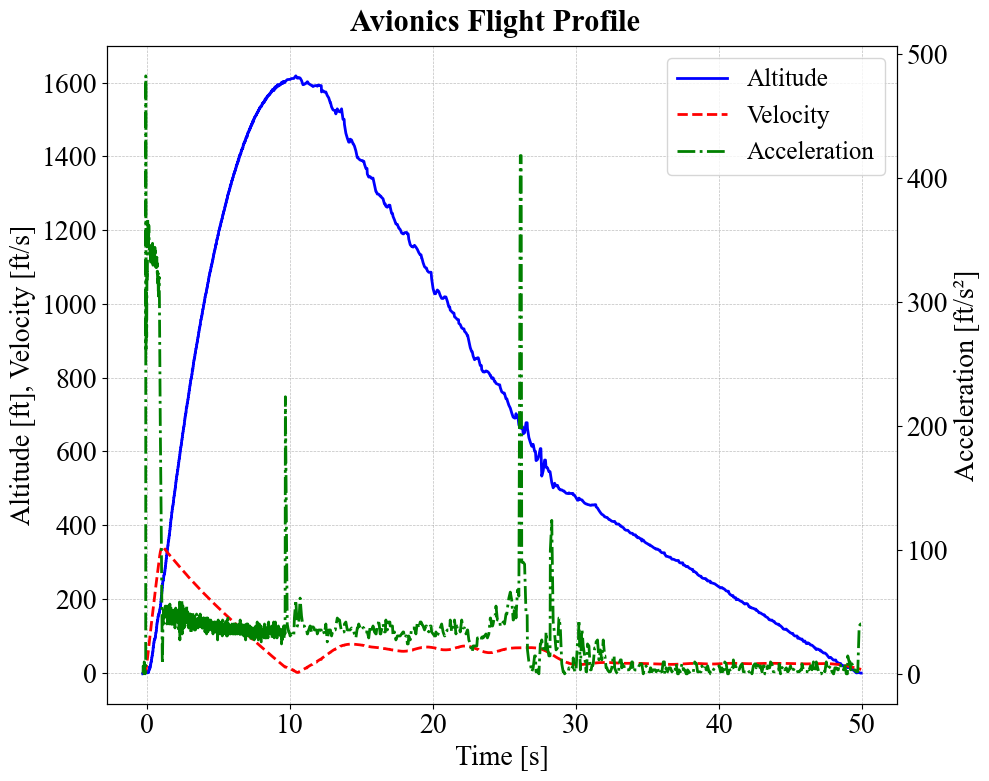

In [ ]:
fig = plt.figure()
fig.set_tight_layout(True)
ax = fig.add_subplot()

ax.plot(data_avionics2['Time [s]'], data_avionics2['Altitude [ft]'], linestyle='-', color='b', label='Altitude', linewidth=2)
ax.plot(data_avionics2['Time [s]'], np.abs(data_avionics2['Velocity [ft/s]']), linestyle='--', color='r', label='Velocity', linewidth=2)

ax2 = ax.twinx()
ax2.plot(data_avionics2['Time [s]'], np.abs(data_avionics2['Acceleration [ft/s²]']), linestyle='-.', color='g', label='Acceleration', linewidth=2)

fig.suptitle('Avionics Flight Profile', y=0.97)
ax.set_xlabel('Time [s]')
ax.set_ylabel('Altitude [ft], Velocity [ft/s]')
ax2.set_ylabel('Acceleration [ft/s²]')

ax.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc='upper right')

# fig.savefig('Subscale Avionics Flight Profile.png', dpi=300)

plt.show()

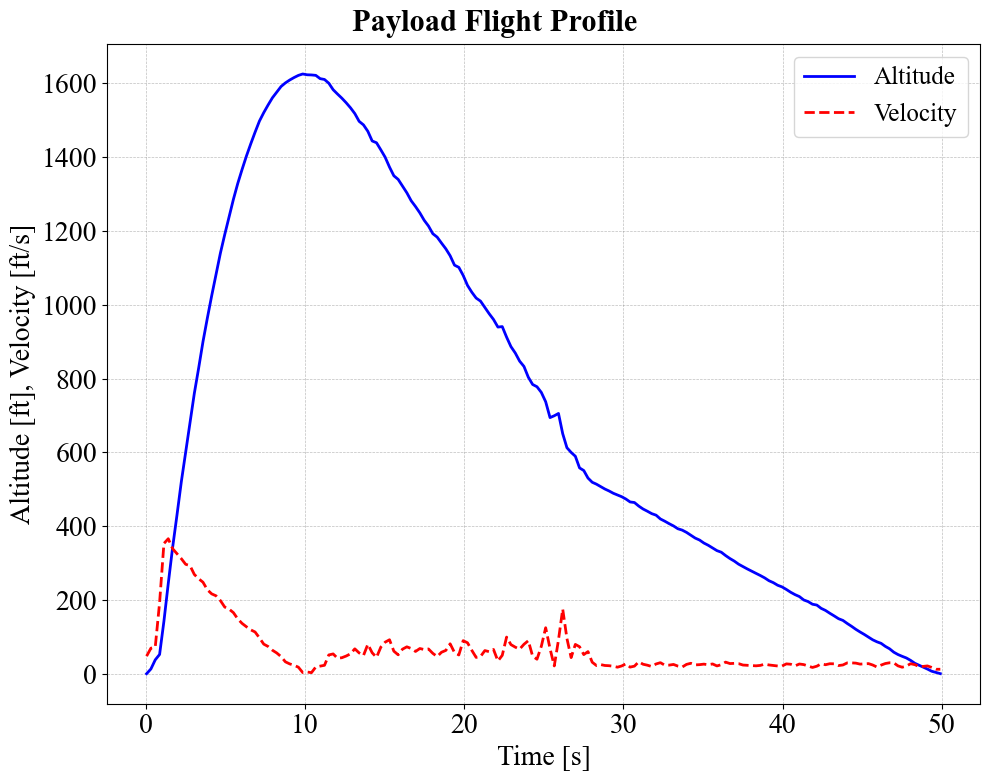

In [ ]:
fig = plt.figure()
fig.set_tight_layout(True)
ax = fig.add_subplot()

ax.plot(data_payload2['Time [s]'], data_payload2['Altitude [ft]'], linestyle='-', color='b', label='Altitude', linewidth=2)
ax.plot(data_payload2['Time [s]'], np.abs(data_payload2['Velocity [ft/s]']), linestyle='--', color='r', label='Velocity', linewidth=2)

# ax2 = ax.twinx()
# ax2.plot(data_payload2['Time [s]'], data_payload2['Acceleration [ft/s²]'], linestyle='-.', color='g', label='Acceleration', linewidth=2)

fig.suptitle('Payload Flight Profile', y=0.97)
ax.set_xlabel('Time [s]')
ax.set_ylabel('Altitude [ft], Velocity [ft/s]')
# ax2.set_ylabel('Acceleration [ft/s²]')

ax.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

h1, l1 = ax.get_legend_handles_labels()
# h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1, l1, loc='upper right')

# fig.savefig('Subscale Payload Flight Profile.png', dpi=300)

plt.show()

Separating data into different phases

In [29]:
# Drogue data
drogue_data_avionics = data_avionics2[(data_avionics2['Time [s]'].values > time_to_apogee_avionics+1.5) & (data_avionics2['Altitude [ft]'].values > 700)]
drogue_data_payload = data_payload2[(data_payload2['Time [s]'].values > time_to_apogee_payload+1.5) & (data_payload2['Altitude [ft]'].values > 700)]

# Main data
main_data_avionics = data_avionics2[(data_avionics2['Time [s]'].values > 28) & (data_avionics2['Altitude [ft]'].values < 700) & (data_avionics2['Altitude [ft]'].values > 5)]
main_data_payload = data_payload2[(data_payload2['Time [s]'].values > 28) & (data_payload2['Altitude [ft]'].values < 700) & (data_payload2['Altitude [ft]'].values > 5)]

Fitting terminal velocity to the descent phases

In [30]:
# Fitting a linear regression model to the drogue data
drogue_fit_avionics = np.polyfit(drogue_data_avionics['Time [s]'], drogue_data_avionics['Altitude [ft]'], 1)
drogue_fit_payload = np.polyfit(drogue_data_payload['Time [s]'], drogue_data_payload['Altitude [ft]'], 1)

# Fitting a linear regression model to the main data
main_fit_avionics = np.polyfit(main_data_avionics['Time [s]'], main_data_avionics['Altitude [ft]'], 1)
main_fit_payload = np.polyfit(main_data_payload['Time [s]'], main_data_payload['Altitude [ft]'], 1)

print(f'Drogue Fit Avionics: {drogue_fit_avionics[0]:.2f} ft/s, {drogue_fit_avionics[1]:.2f} ft')
print(f'Drogue Fit Payload: {drogue_fit_payload[0]:.2f} ft/s, {drogue_fit_payload[1]:.2f} ft')
print(f'Main Fit Avionics: {main_fit_avionics[0]:.2f} ft/s, {main_fit_avionics[1]:.2f} ft')
print(f'Main Fit Payload: {main_fit_payload[0]:.2f} ft/s, {main_fit_payload[1]:.2f} ft')

Drogue Fit Avionics: -65.63 ft/s, 2377.12 ft
Drogue Fit Payload: -63.87 ft/s, 2350.26 ft
Main Fit Avionics: -24.41 ft/s, 1207.65 ft
Main Fit Payload: -24.34 ft/s, 1206.33 ft


Showing the velocity fits

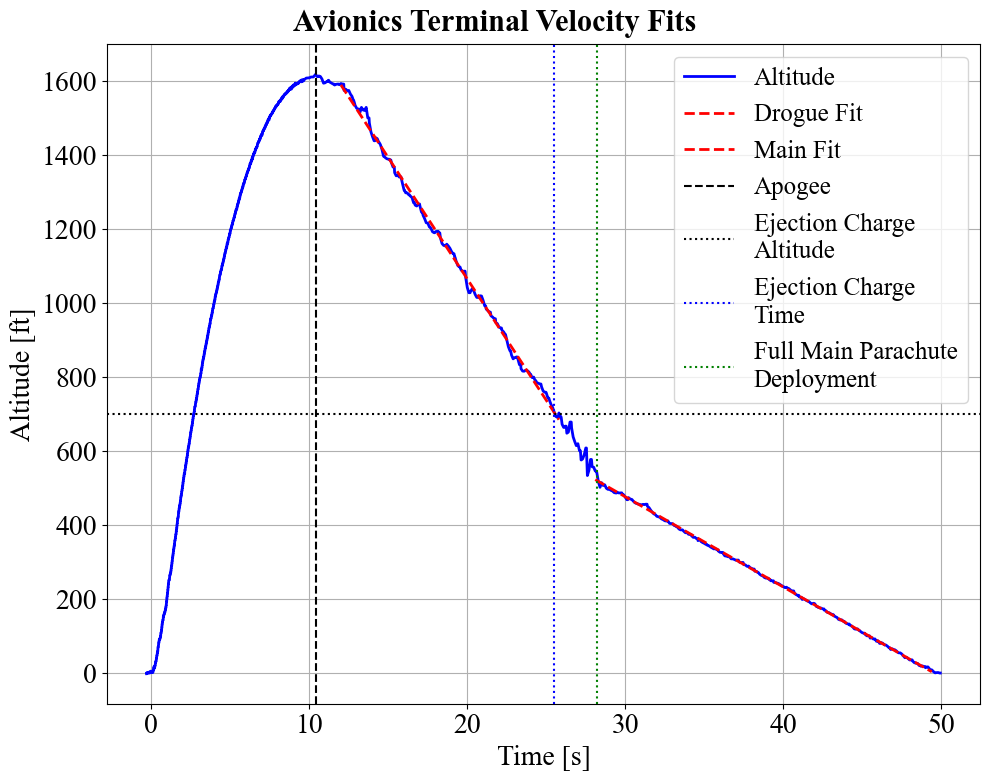

In [39]:
fig = plt.figure()
fig.set_tight_layout(True)
ax = fig.add_subplot()

ax.plot(data_avionics2['Time [s]'], data_avionics2['Altitude [ft]'], linestyle='-', color='b', label='Altitude', linewidth=2)

ax.plot(drogue_data_avionics['Time [s]'], np.polyval(drogue_fit_avionics, drogue_data_avionics['Time [s]']), linestyle='--', color='r', linewidth=2, label='Drogue Fit')

ax.plot(main_data_avionics['Time [s]'], np.polyval(main_fit_avionics, main_data_avionics['Time [s]']), linestyle='--', color='r', linewidth=2, label='Main Fit')

ax.axvline(time_to_apogee_avionics, color='k', linestyle='dashed', label='Apogee')
ax.axhline(700, color='k', linestyle=':', label='Ejection Charge\nAltitude')

ax.axvline(25.5, color='b', linestyle=':', label='Ejection Charge\nTime')
ax.axvline(28.2, color='g', linestyle=':', label='Full Main Parachute\nDeployment')

fig.suptitle('Avionics Terminal Velocity Fits', y=0.97)
ax.set_xlabel('Time [s]')
ax.set_ylabel('Altitude [ft]')
ax.grid(True)

ax.legend(loc='upper right', ncol=1)

plt.show()

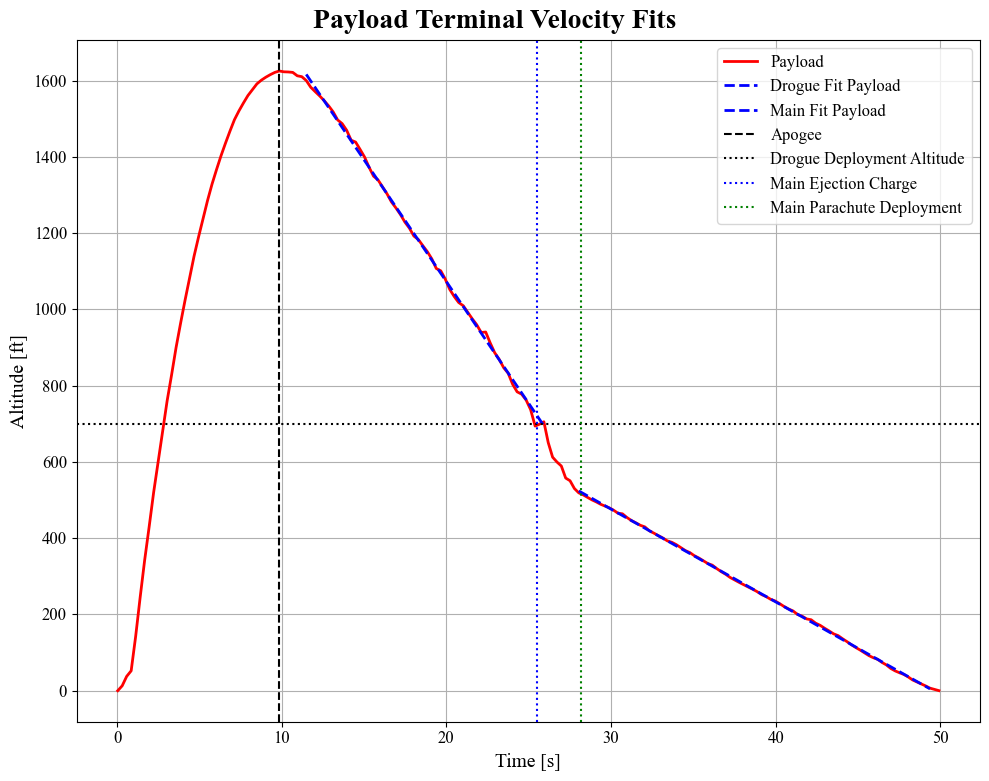

In [ ]:
fig = plt.figure()
fig.set_tight_layout(True)
ax = fig.add_subplot()

# ax.plot(data_avionics2['Time [s]'], data_avionics2['Altitude [ft]'], linestyle='-', color='r', label='Avionics', linewidth=2)
ax.plot(data_payload2['Time [s]'], data_payload2['Altitude [ft]'], linestyle='-', color='r', label='Payload', linewidth=2)

# ax.plot(drogue_data_avionics['Time [s]'], np.polyval(drogue_fit_avionics, drogue_data_avionics['Time [s]']), linestyle='--', color='b', linewidth=2, label='Drogue Fit Avionics')
ax.plot(drogue_data_payload['Time [s]'], np.polyval(drogue_fit_payload, drogue_data_payload['Time [s]']), linestyle='--', color='b', linewidth=2, label='Drogue Fit Payload')

# ax.plot(main_data_avionics['Time [s]'], np.polyval(main_fit_avionics, main_data_avionics['Time [s]']), linestyle='--', color='b', linewidth=2, label='Main Fit Avionics')
ax.plot(main_data_payload['Time [s]'], np.polyval(main_fit_payload, main_data_payload['Time [s]']), linestyle='--', color='b', linewidth=2, label='Main Fit Payload')

ax.axvline(time_to_apogee_payload, color='k', linestyle='dashed', label='Apogee')
ax.axhline(700, color='k', linestyle=':', label='Drogue Deployment Altitude')

ax.axvline(25.5, color='b', linestyle=':', label='Main Ejection Charge')
ax.axvline(28.2, color='g', linestyle=':', label='Main Parachute Deployment')

fig.suptitle('Payload Terminal Velocity Fits', y=0.97)
ax.set_xlabel('Time [s]')
ax.set_ylabel('Altitude [ft]')
ax.grid(True)

ax.legend(loc='upper right')

plt.show()

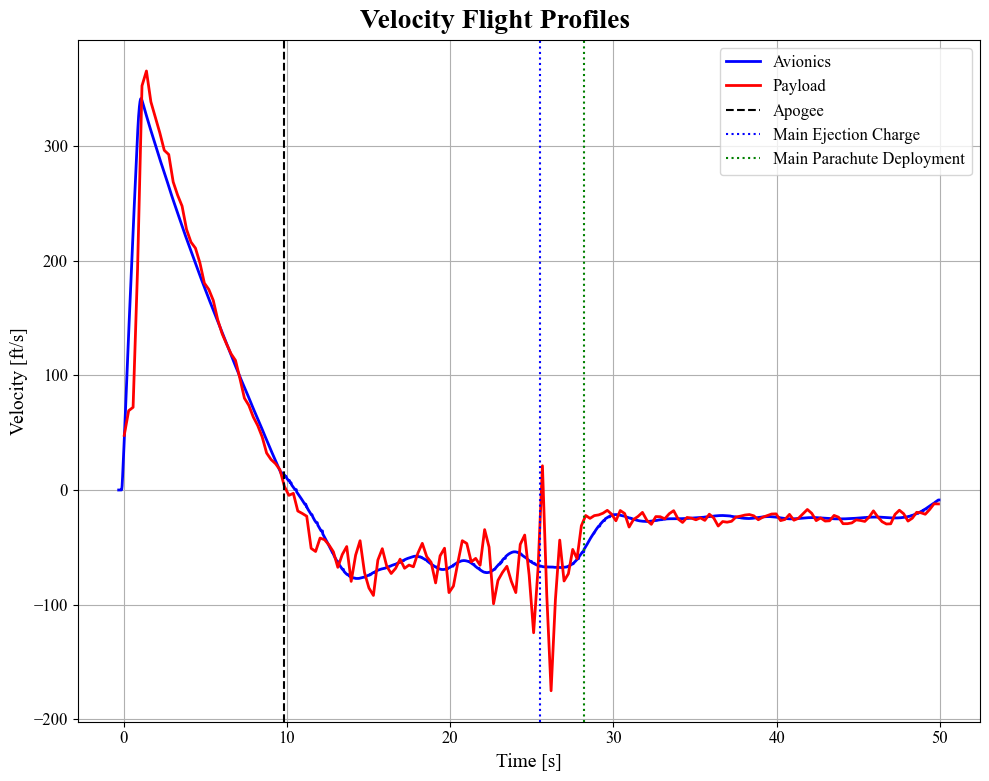

In [ ]:
fig = plt.figure()
fig.set_tight_layout(True)
ax = fig.add_subplot()

ax.plot(data_avionics2['Time [s]'], data_avionics2['Velocity [ft/s]'], linestyle='-', color='b', label='Avionics', linewidth=2)
ax.plot(data_payload2['Time [s]'], data_payload2['Velocity [ft/s]'], linestyle='-', color='r', label='Payload', linewidth=2)

# ax.plot(drogue_data_avionics['Time [s]'], np.polyval(drogue_fit_avionics, drogue_data_avionics['Time [s]']), linestyle='--', color='b', linewidth=2, label='Drogue Fit Avionics')
# ax.plot(drogue_data_payload['Time [s]'], np.polyval(drogue_fit_payload, drogue_data_payload['Time [s]']), linestyle='--', color='b', linewidth=2, label='Drogue Fit Payload')

# ax.plot(main_data_avionics['Time [s]'], np.polyval(main_fit_avionics, main_data_avionics['Time [s]']), linestyle='--', color='b', linewidth=2, label='Main Fit Avionics')
# ax.plot(main_data_payload['Time [s]'], np.polyval(main_fit_payload, main_data_payload['Time [s]']), linestyle='--', color='b', linewidth=2, label='Main Fit Payload')

ax.axvline(time_to_apogee_payload, color='k', linestyle='dashed', label='Apogee')
# ax.axhline(700, color='k', linestyle=':', label='Drogue Deployment Altitude')

ax.axvline(25.5, color='b', linestyle=':', label='Main Ejection Charge')
ax.axvline(28.2, color='g', linestyle=':', label='Main Parachute Deployment')

fig.suptitle('Velocity Flight Profiles', y=0.97)
ax.set_xlabel('Time [s]')
ax.set_ylabel('Velocity [ft/s]')
ax.grid(True)

ax.legend(loc='upper right')

plt.show()

Seeing temperature

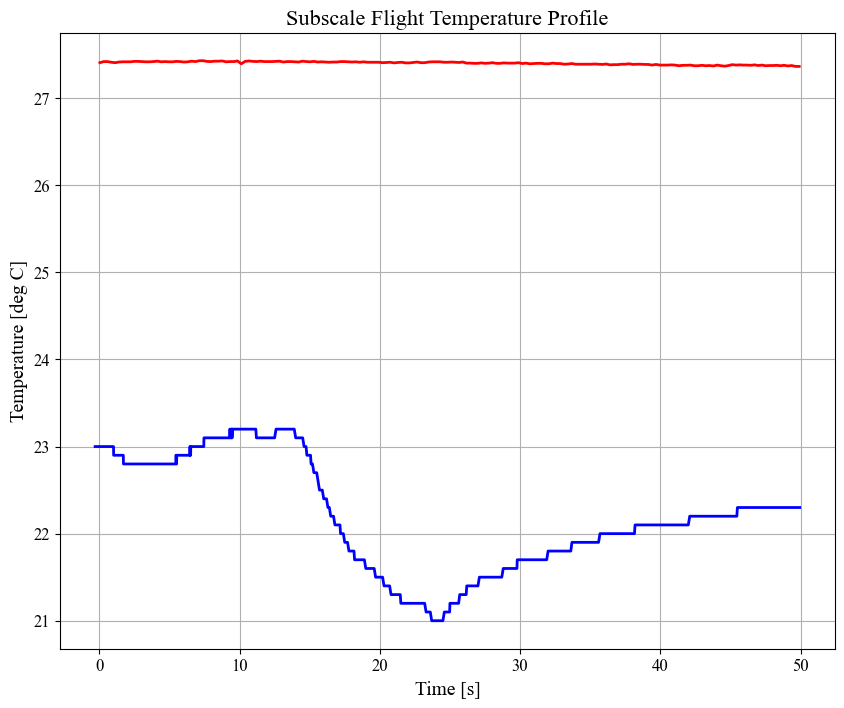

In [ ]:
fig = plt.figure()
ax = fig.add_subplot()

ax.plot(data_payload2['Time [s]'], data_payload2['Temperature [deg C]'], linestyle='-', color='r', label='Payload', linewidth=2)
ax.plot(data_avionics2['Time [s]'], data_avionics2['temperature'], linestyle='-', color='b', label='Avionics', linewidth=2)

ax.set_title('Subscale Flight Temperature Profile')
ax.set_xlabel('Time [s]')
ax.set_ylabel('Temperature [deg C]')
ax.grid(True)

plt.show()

Seeing pressure

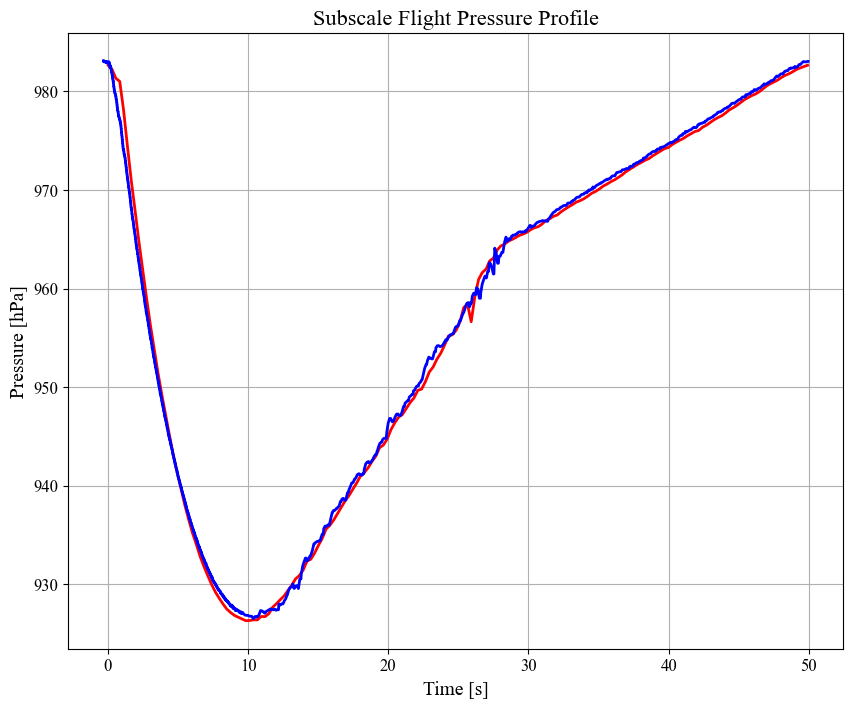

In [ ]:
fig = plt.figure()
ax = fig.add_subplot()

ax.plot(data_payload2['Time [s]'], data_payload2['Pressure [hPa]'], linestyle='-', color='r', label='Payload', linewidth=2)
ax.plot(data_avionics2['Time [s]'], data_avionics2['pressure'] / 100, linestyle='-', color='b', label='Avionics', linewidth=2)

ax.set_title('Subscale Flight Pressure Profile')
ax.set_xlabel('Time [s]')
ax.set_ylabel('Pressure [hPa]')
ax.grid(True)

plt.show()

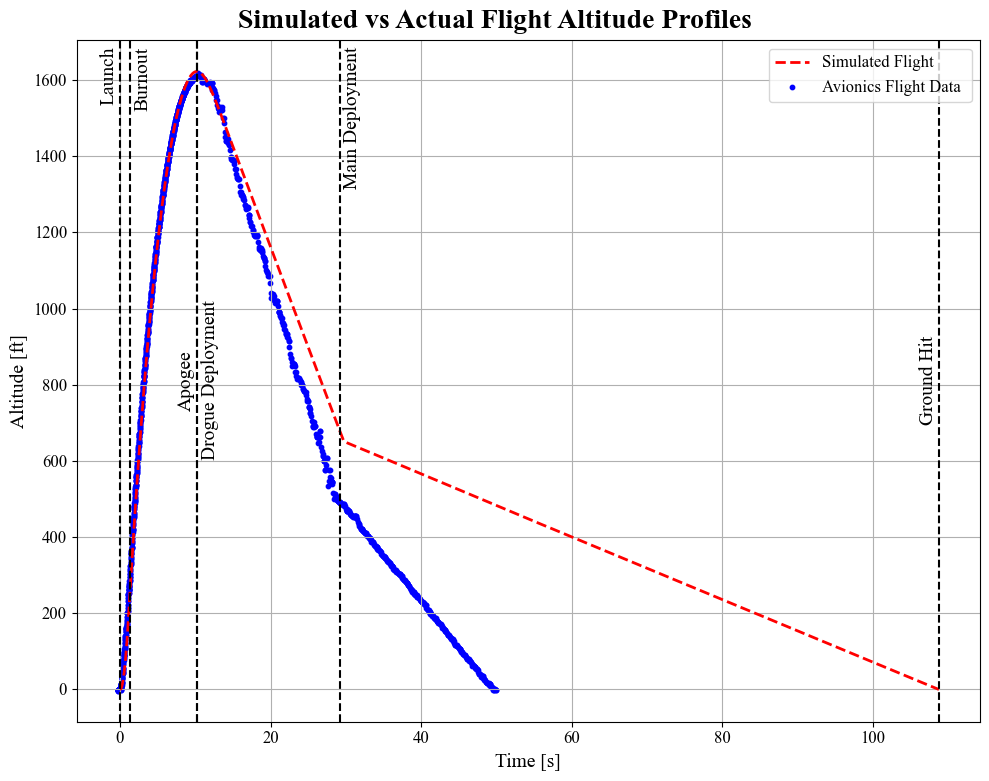

In [ ]:
fig, ax = openrocket_to_plot('Subscale OpenRocket Launch Conditions.csv', color='r', label='Simulated Flight', linestyle='--')

# ax.plot(data_sim_launch_cond['Time (s)'], data_sim_launch_cond['Altitude (ft)'], linestyle='--', color='r', label='Launch Conditions', linewidth=2)
# ax.plot(data_avionics2['Time [s]'], data_avionics2['Altitude [ft]'], linestyle='-', color='b', label='Avionics Flight Data ', linewidth=2)
# ax.plot(data_payload2['Time [s]'], data_payload2['Altitude [ft]'], linestyle='-', color='g', label='Payload Flight Data ', linewidth=2)
ax.scatter(data_avionics2['Time [s]'], data_avionics2['Altitude [ft]'], c='b', label='Avionics Flight Data ', s=10)
# ax.scatter(data_payload2['Time [s]'], data_payload2['Altitude [ft]'], c='g', label='Payload Flight Data ', s=10)

ax.legend(loc='upper right')
fig.suptitle('Simulated vs Actual Flight Altitude Profiles', y=0.97)

# fig.savefig('Subscale_Simulated_Flight_Profile_Comparison.png', dpi=300)

plt.show()

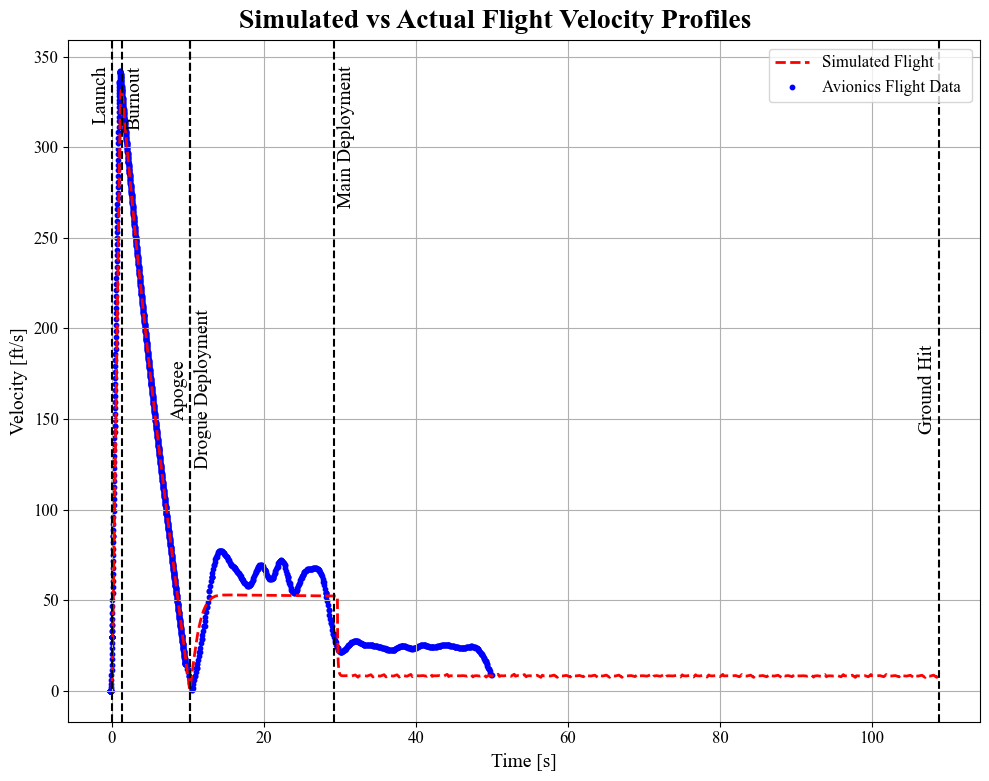

In [ ]:
fig, ax = openrocket_to_plot('Subscale OpenRocket Launch Conditions.csv', color='r', label='Simulated Flight', linestyle='--', plot_type='velocity')

# ax.plot(data_avionics2['Time [s]'], np.abs(data_avionics2['Velocity [ft/s]']), linestyle='-', color='b', label='Avionics Flight Data ', linewidth=2)
# ax.plot(data_payload2['Time [s]'], np.abs(data_payload2['Velocity [ft/s]']), linestyle='-', color='g', label='Payload Flight Data ', linewidth=2)
ax.scatter(data_avionics2['Time [s]'], np.abs(data_avionics2['Velocity [ft/s]']), c='b', label='Avionics Flight Data ', s=10)
# ax.scatter(data_payload2['Time [s]'], np.abs(data_payload2['Velocity [ft/s]']), c='g', label='Payload Flight Data ', s=10)

ax.legend(loc='upper right')
fig.suptitle('Simulated vs Actual Flight Velocity Profiles', y=0.97)

# fig.savefig('Subscale_Simulated_Flight_Profile_Comparison.png', dpi=300)

plt.show()

Comparing the actual and simulated flights through interpolation and plotting

In [ ]:
common_times = np.linspace(0, max(data_sim_standard_cond['Time (s)'].max(), data_sim_launch_cond['Time (s)'].max()), num=1000)

# Interpolating avionics data
interp_avionics = interpolate.interp1d(data_avionics2['Time [s]'], data_avionics2['Altitude [ft]'], kind='linear', fill_value=0, bounds_error=False)
interp_altitudes_avionics = interp_avionics(common_times)

# Interpolating payload data
interp_payload = interpolate.interp1d(data_payload2['Time [s]'], data_payload2['Altitude [ft]'], kind='linear', fill_value=0, bounds_error=False)
interp_altitudes_payload = interp_payload(common_times)

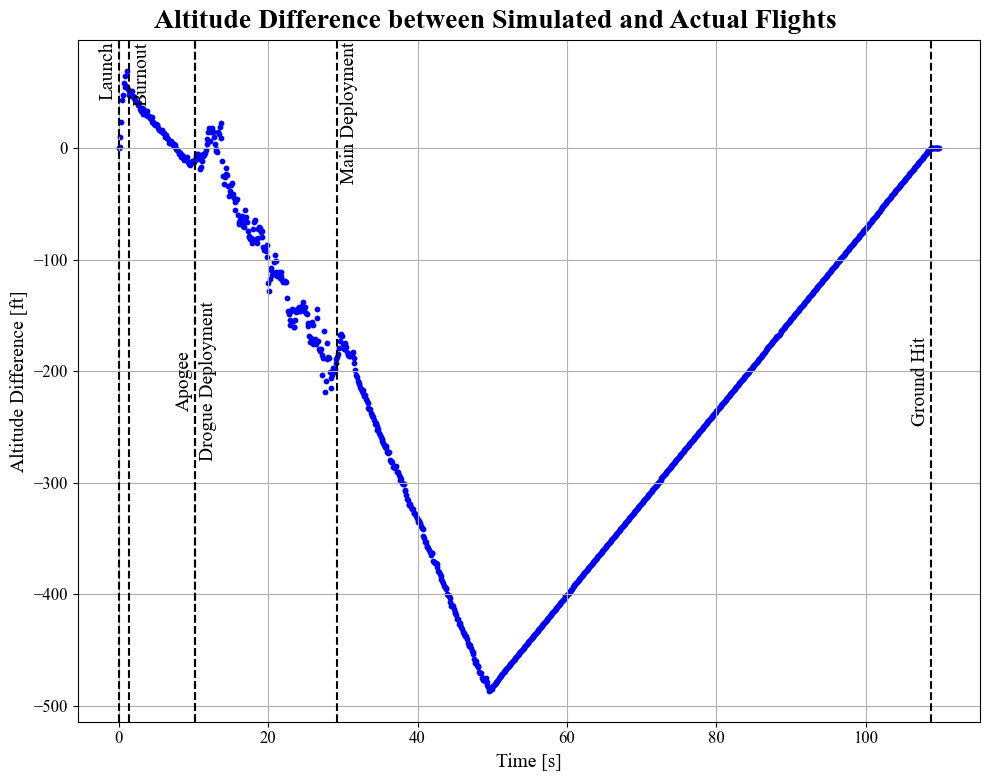

In [ ]:
fig, ax = openrocket_to_plot('Subscale OpenRocket Launch Conditions.csv', code_to_run="ax.scatter(common_times, interp_altitudes_avionics - interp_altitudes_launch, c='b', s=10)")

# ax.plot(common_times, interp_altitudes_avionics - interp_altitudes_launch, linestyle='-', color='b', label='Avionics - Simulated', linewidth=2)

fig.suptitle('Altitude Difference between Simulated and Actual Flights', y=0.97)
# fig.set_tight_layout(True)

# ax.set_xlim(-2, 32)

ax.set_xlabel('Time [s]')
ax.set_ylabel('Altitude Difference [ft]')

# ax.legend(loc='upper center')

ax.grid(True)

# fig.savefig('Subscale_Altitude_Difference_Simulated_vs_Actual.png', dpi=300)

plt.show()

Plotting comparison between payload and avionics altitudes

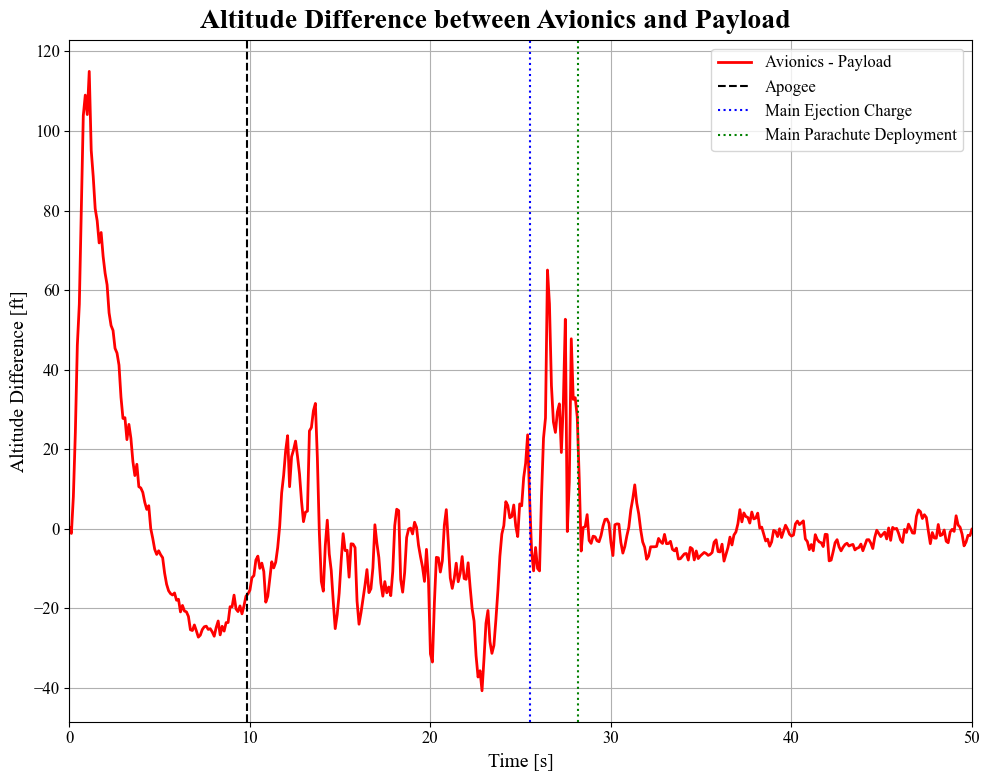

In [ ]:
fig = plt.figure()
fig.set_tight_layout(True)
ax = fig.add_subplot()

ax.plot(common_times, interp_altitudes_avionics - interp_altitudes_payload, linestyle='-', color='r', label='Avionics - Payload', linewidth=2)

ax.axvline(time_to_apogee_payload, color='k', linestyle='dashed', label='Apogee')
ax.axvline(25.5, color='b', linestyle=':', label='Main Ejection Charge')
ax.axvline(28.2, color='g', linestyle=':', label='Main Parachute Deployment')
# ax.text(time_to_apogee_payload - 0.5, np.mean(ax.get_ylim()), 'Apogee', rotation=90, verticalalignment='center', horizontalalignment='right', fontsize=14)

fig.suptitle('Altitude Difference between Avionics and Payload', y=0.97)

ax.set_xlim(0, 50)

ax.set_xlabel('Time [s]')
ax.set_ylabel('Altitude Difference [ft]')

ax.grid(True)

ax.legend(loc='upper right')

plt.show()

## Calculating $C_D$ from the descent data

Defining constants

In [ ]:
T0 = 10 # deg C
P0 = 98320 # Pa

# Calculating density
R = 287.05 # J/(kg·K)
T_kelvin = T0 + 273.15 # Convert to Kelvin
rho0 = P0 / (R * T_kelvin) # kg/m^3

Drogue parachute descent

In [ ]:
velocity_drogue_avionics = drogue_fit_avionics[0]
velocity_drogue_payload = drogue_fit_payload[0]

# Calculating reference area
D_drogue = 24 # in
A_drogue = np.pi * (D_drogue * 0.0254 / 2)**2 # m^2

# Weight of rocket
W_rocket = 5.14012 * 9.81 # N

Cd_drogue_avionics = (2 * W_rocket) / (rho0 * A_drogue * (velocity_drogue_avionics * 0.3048)**2)
Cd_drogue_payload = (2 * W_rocket) / (rho0 * A_drogue * (velocity_drogue_payload * 0.3048)**2)

print(f'Drogue Parachute Drag Coefficient (Avionics): {Cd_drogue_avionics:.2f}')
print(f'Drogue Parachute Drag Coefficient (Payload): {Cd_drogue_payload:.2f}')

Drogue Parachute Drag Coefficient (Avionics): 0.71
Drogue Parachute Drag Coefficient (Payload): 0.75


Main parachute descent

In [ ]:
velocity_main_avionics = main_fit_avionics[0]
velocity_main_payload = main_fit_payload[0]

# Calculating reference area
D_main = 100 # in
A_main = np.pi * (D_main * 0.0254 / 2)**2 # m^2

# Weight of rocket
W_rocket = 5.14012 * 9.81 # N

Cd_main_avionics = (2 * W_rocket) / (rho0 * A_main * (velocity_main_avionics * 0.3048)**2)
Cd_main_payload = (2 * W_rocket) / (rho0 * A_main * (velocity_main_payload * 0.3048)**2)

print(f'Main Parachute Drag Coefficient (Avionics): {Cd_main_avionics:.2f}')
print(f'Main Parachute Drag Coefficient (Payload): {Cd_main_payload:.2f}')

Main Parachute Drag Coefficient (Avionics): 0.30
Main Parachute Drag Coefficient (Payload): 0.30


## OpenRocket simulation plots with new $C_D$ values

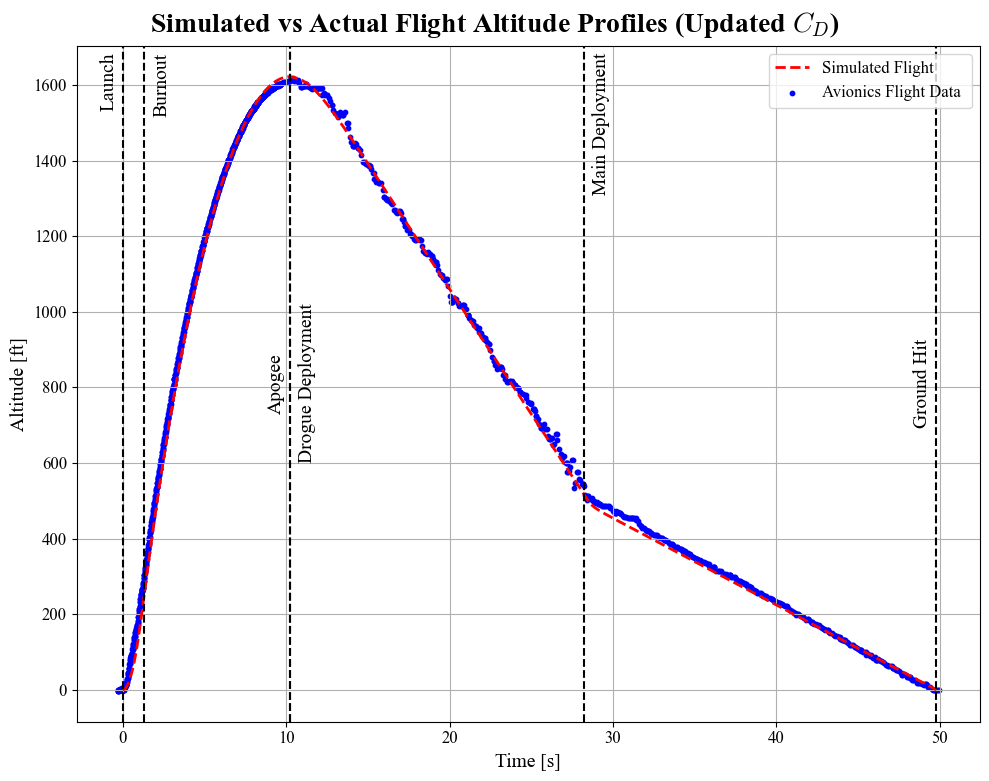

In [ ]:
fig, ax = openrocket_to_plot('Subscale OpenRocket Launch Conditions New.csv', color='r', label='Simulated Flight', linestyle='--')

ax.scatter(data_avionics2['Time [s]'], data_avionics2['Altitude [ft]'], c='b', label='Avionics Flight Data ', s=10)
# ax.plot(data_payload2['Time [s]'], data_payload2['Altitude [ft]'], linestyle='-', color='g', label='Payload Flight Data ', linewidth=2)

fig.suptitle('Simulated vs Actual Flight Altitude Profiles (Updated $C_D$)', y=0.97)

ax.legend(loc='upper right')

plt.show()

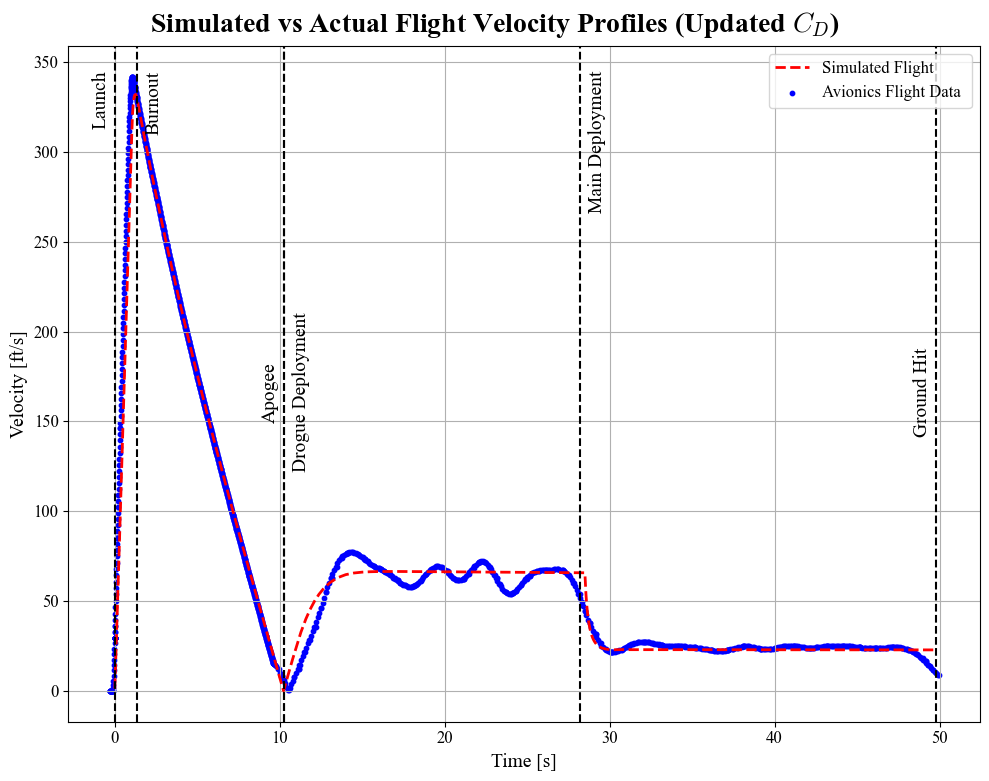

In [ ]:
fig, ax = openrocket_to_plot('Subscale OpenRocket Launch Conditions New.csv', color='r', label='Simulated Flight', linestyle='--', plot_type='velocity')

ax.scatter(data_avionics2['Time [s]'], np.abs(data_avionics2['Velocity [ft/s]']), c='b', label='Avionics Flight Data ', s=10)
# ax.plot(data_payload2['Time [s]'], data_payload2['Altitude [ft]'], linestyle='-', color='g', label='Payload Flight Data ', linewidth=2)

fig.suptitle('Simulated vs Actual Flight Velocity Profiles (Updated $C_D$)', y=0.97)

ax.legend(loc='upper right')

plt.show()

In [ ]:
data_sim_launch_cond_new = pd.read_csv('Subscale OpenRocket Launch Conditions New.csv', comment='#')

# Comparing datasets by interpolating the altitudes
sim_common_times_new = np.linspace(0, data_sim_launch_cond_new['Time (s)'].max(), num=1000)

interp_sim_launch_new = interpolate.interp1d(data_sim_launch_cond_new['Time (s)'], data_sim_launch_cond_new['Altitude (ft)'], kind='linear', fill_value=0, bounds_error=False)

interp_altitudes_launch_new = interp_sim_launch_new(sim_common_times_new)
interp_altitudes_avionics_new = interp_avionics(sim_common_times_new)

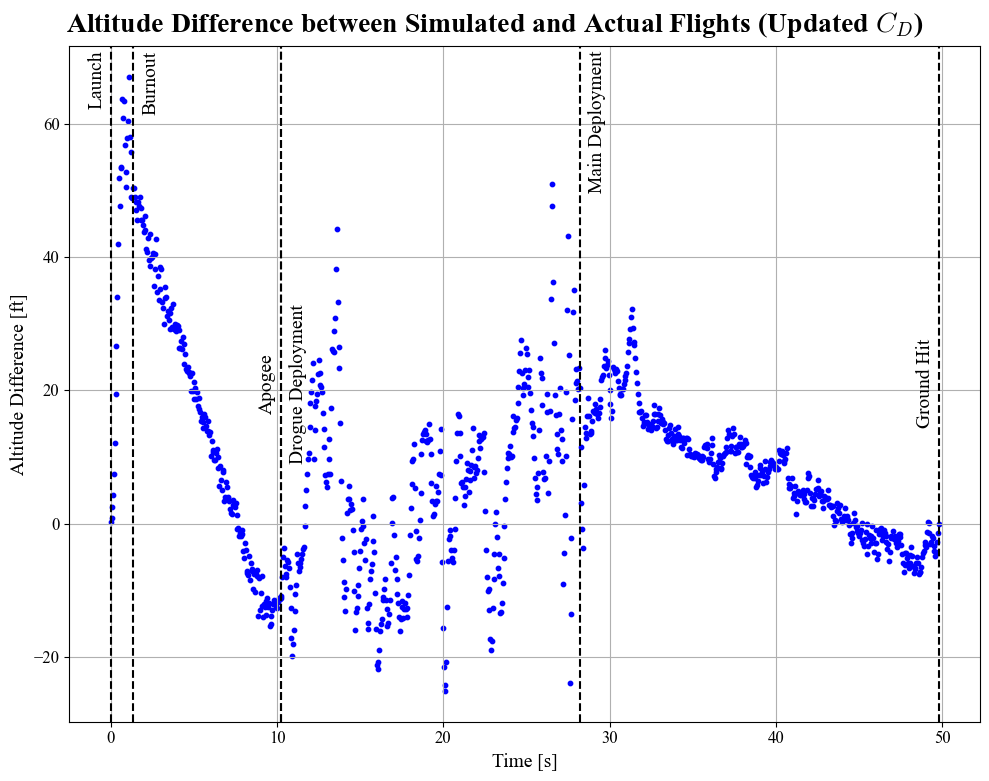

In [ ]:
fig, ax = openrocket_to_plot('Subscale OpenRocket Launch Conditions New.csv', code_to_run="ax.scatter(sim_common_times_new, interp_altitudes_avionics_new - interp_altitudes_launch_new, c='b', s=10)")

# ax.plot(common_times, interp_altitudes_avionics - interp_altitudes_launch, linestyle='-', color='r', label='Before $C_D$ Update', linewidth=2)

fig.suptitle('Altitude Difference between Simulated and Actual Flights (Updated $C_D$)', y=0.97)
# fig.set_tight_layout(True)

# ax.set_xlim(-2, 32)

ax.set_xlabel('Time [s]')
ax.set_ylabel('Altitude Difference [ft]')

# ax.legend(loc='upper right')

ax.grid(True)

# fig.savefig('Subscale_Altitude_Difference_Simulated_vs_Actual.png', dpi=300)

plt.show()